### 7 · Reranking — FlashRank for CMS3 Log Debugging

Dense retrieval gets us candidate evidence quickly, but debugging answers depend on putting the most explanatory chunks first. This notebook uses FlashRank as the reranking layer for CMS3 logs.

### Pattern
```
Retrieve wide (summary + event chunks) → FlashRank rerank → keep top evidence → answer
```

This is the same architectural idea the app now uses in the `rerank_docs` node.


In [8]:
import json
import os
import re
from pathlib import Path
from typing import TypedDict

from dotenv import load_dotenv
from flashrank import Ranker
from langchain_community.document_compressors import FlashrankRerank
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore
from langgraph.graph import END, StateGraph
from pinecone import Pinecone

# Load environment variables from the project root.
NOTEBOOK_DIR = Path.cwd()
load_dotenv(dotenv_path=NOTEBOOK_DIR.parent / ".env", override=True)

EMBEDDING_MODEL = "text-embedding-3-small"
ANSWER_MODEL = "gpt-4o"
INDEX_NAME = os.getenv("PINECONE_INDEX_NAME", "move-mind-ai")
INDEX_HOST = os.getenv("PINECONE_INDEX_HOST")
NAMESPACE = os.getenv("PINECONE_NAMESPACE", "cms3-logs")
host_label = INDEX_HOST if INDEX_HOST else "<not set>"

required_env = ["OPENAI_API_KEY", "PINECONE_API_KEY"]
missing = [key for key in required_env if not os.getenv(key)]
if missing:
    raise ValueError(f"Missing required environment variables: {missing}")

embeddings = OpenAIEmbeddings(model=EMBEDDING_MODEL)
pc = Pinecone(api_key=os.environ["PINECONE_API_KEY"])
index = pc.Index(host=INDEX_HOST) if INDEX_HOST else pc.Index(INDEX_NAME)
vectorstore = PineconeVectorStore(
    index=index, embedding=embeddings, namespace=NAMESPACE
)
answer_llm = ChatOpenAI(model=ANSWER_MODEL, temperature=0)
reranker = FlashrankRerank(client=Ranker(model_name="ms-marco-TinyBERT-L-2-v2"))

print(f"Connected to Pinecone index: {INDEX_NAME}")
print(f"Namespace: {NAMESPACE}")
print(f"Host override: {host_label}")

Connected to Pinecone index: move-mind-ai
Namespace: cms3-logs
Host override: https://move-mind-ai-g57210f.svc.aped-4627-b74a.pinecone.io


---
### Step 1 — Retrieval Helpers

We keep the same CMS3 retrieval logic as the app: scope by business key first, then search both summary and event chunks.


In [9]:
CID_PATTERN = re.compile(r"\bCID\s*[:#-]?\s*(\d+)\b", re.IGNORECASE)
PAGE_PATTERN = re.compile(r"(/[A-Za-z0-9._/-]+)")


def extract_customer_id(query: str) -> str | None:
    match = CID_PATTERN.search(query)
    return match.group(1) if match else None


def extract_page_path(query: str) -> str | None:
    match = PAGE_PATTERN.search(query)
    return match.group(1) if match else None


def build_scope_filter(question: str) -> dict | None:
    metadata_filter = {}
    customer_id = extract_customer_id(question)
    page_path = extract_page_path(question)
    if customer_id:
        metadata_filter["customer_id"] = customer_id
    if page_path:
        metadata_filter["page_path"] = page_path
    return metadata_filter or None


def retrieve_candidates(
    question: str, *, k_summary: int = 2, k_events: int = 10
) -> list[Document]:
    base_filter = build_scope_filter(question) or {}
    summary_filter = {"chunk_type": "execution_summary"}
    if "customer_id" in base_filter:
        summary_filter["customer_id"] = base_filter["customer_id"]
    event_filter = {"chunk_type": "event", **base_filter}

    summary_docs = vectorstore.similarity_search(
        question, k=k_summary, filter=summary_filter
    )
    event_docs = vectorstore.similarity_search(
        question, k=k_events, filter=event_filter
    )

    unique_docs = []
    seen = set()
    for doc in summary_docs + event_docs:
        key = (doc.page_content, json.dumps(doc.metadata, sort_keys=True, default=str))
        if key in seen:
            continue
        seen.add(key)
        unique_docs.append(doc)
    return unique_docs


def show_docs(docs, label):
    print(f"\n{label} ({len(docs)} chunks)")
    print("-" * 100)
    for i, doc in enumerate(docs, start=1):
        metadata = doc.metadata
        print(
            f"[{i}] type={metadata.get('chunk_type')} | cid={metadata.get('customer_id')} | page={metadata.get('page_path')} | action={metadata.get('action')}"
        )
        print(doc.page_content[:350])
        print()


print("Reranking helpers ready.")

Reranking helpers ready.


---
### Step 2 — Inspect the Raw Candidate Set

The question below is specific enough to retrieve the right customer and route, but broad enough that multiple event chunks still compete for attention. This is where reranking helps.


In [10]:
query = (
    "For CID 7093495, which UI condition evaluated to true on /ccflownew/quote/booking?"
)
candidates = retrieve_candidates(query)
print(f"Query: {query}")
show_docs(candidates, "Raw retrieved candidates")

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


Query: For CID 7093495, which UI condition evaluated to true on /ccflownew/quote/booking?

Raw retrieved candidates (6 chunks)
----------------------------------------------------------------------------------------------------
[1] type=execution_summary | cid=7093495 | page=None | action=None
group_key: cid:7093495 | exec:exec-7093495-95fdafb2-9657-4cf0-aed9-31d98658fd88
journey_id: ccflownew
customer_ids: ['7093495']
execution_ids: ['exec-7093495-95fdafb2-9657-4cf0-aed9-31d98658fd88']
event_count: 78
step_range: 1 -> 78
status_counts: {'success': 78}
top_actions: {'route_entered': 22, 'evaluate_ui_condition': 16, 'patch_context': 11, '

[2] type=event | cid=7093495 | page=/ccflownew/quote/booking | action=evaluate_ui_condition
timestamp: 2026-04-02T06:52:29.027Z
journey_id: ccflownew
execution_id: exec-7093495-95fdafb2-9657-4cf0-aed9-31d98658fd88
customer_id: 7093495
step_order: 77
action: evaluate_ui_condition
event_type: ui_condition
status: success
level: info
page_path: /ccflowne

---
### Step 3 — Apply FlashRank Reranking

FlashRank scores the query against each chunk more precisely than the original vector search, then returns the best evidence first.


In [11]:
reranked_docs = [] if not candidates else reranker.compress_documents(candidates, query)
show_docs(reranked_docs, "FlashRank reranked evidence")


FlashRank reranked evidence (3 chunks)
----------------------------------------------------------------------------------------------------
[1] type=execution_summary | cid=7093495 | page=None | action=None
group_key: cid:7093495 | exec:exec-7093495-95fdafb2-9657-4cf0-aed9-31d98658fd88
journey_id: ccflownew
customer_ids: ['7093495']
execution_ids: ['exec-7093495-95fdafb2-9657-4cf0-aed9-31d98658fd88']
event_count: 78
step_range: 1 -> 78
status_counts: {'success': 78}
top_actions: {'route_entered': 22, 'evaluate_ui_condition': 16, 'patch_context': 11, '

[2] type=event | cid=7093495 | page=/ccflownew/quote/booking | action=evaluate_ui_condition
timestamp: 2026-04-02T06:52:29.027Z
journey_id: ccflownew
execution_id: exec-7093495-95fdafb2-9657-4cf0-aed9-31d98658fd88
customer_id: 7093495
step_order: 77
action: evaluate_ui_condition
event_type: ui_condition
status: success
level: info
page_path: /ccflownew/quote/booking
source: ScriptedForm
message: UI condition evaluated
condition: true ==

---
### Step 4 — Build a Small Reranking Graph

This mirrors the app pattern: retrieve wide, rerank, then answer from the reranked set only.


In [12]:
class GraphState(TypedDict, total=False):
    question: str
    documents: list[Document]
    reranked_documents: list[Document]
    answer: str


ANSWER_PROMPT = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a CMS3 debugging assistant. Answer using ONLY the provided logs. "
            "If the logs do not contain enough evidence, say so clearly.\n\nContext:\n{context}",
        ),
        ("human", "{question}"),
    ]
)

answer_chain = ANSWER_PROMPT | answer_llm | StrOutputParser()


def retrieve_docs(state: dict) -> dict:
    docs = retrieve_candidates(state["question"])
    print(f"  [retrieve] → {len(docs)} candidates")
    return {"documents": docs}


def rerank_docs(state: dict) -> dict:
    if not state["documents"]:
        print("  [rerank] → no candidates, skipping rerank")
        return {"reranked_documents": []}
    reranked = reranker.compress_documents(state["documents"], state["question"])
    print(f"  [rerank] → {len(state['documents'])} to {len(reranked)}")
    return {"reranked_documents": reranked}


def generate_answer(state: dict) -> dict:
    context = "\n\n---\n\n".join(
        doc.page_content for doc in state["reranked_documents"]
    )
    answer = answer_chain.invoke({"question": state["question"], "context": context})
    print(f"  [generate] → {len(answer)} chars")
    return {"answer": answer}


workflow = StateGraph(GraphState)
workflow.add_node("retrieve_docs", retrieve_docs)
workflow.add_node("rerank_docs", rerank_docs)
workflow.add_node("generate_answer", generate_answer)

workflow.set_entry_point("retrieve_docs")
workflow.add_edge("retrieve_docs", "rerank_docs")
workflow.add_edge("rerank_docs", "generate_answer")
workflow.add_edge("generate_answer", END)

rerank_graph = workflow.compile()
print("Reranking graph compiled.")

Reranking graph compiled.


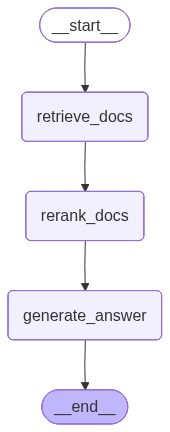

In [13]:
from IPython.display import Image, display

display(Image(rerank_graph.get_graph().draw_mermaid_png()))

---
### Step 5 — Compare Answers: Baseline vs Reranked

The baseline answer uses the raw top candidates directly. The reranked answer uses FlashRank to prioritize stronger evidence first.


In [14]:
TEST_QUERIES = [
    "For CID 7093495, which UI condition evaluated to true on /ccflownew/quote/booking?",
    "For CID 7093495, what happened after /ccflownew/move-scope?",
    "For CID 7093495, why did it end up on /ccflownew/quote/booking?",
]

for query in TEST_QUERIES:
    print("=" * 100)
    print(f"Query: {query}")

    baseline_docs = retrieve_candidates(query)[:5]
    baseline_context = "\n\n---\n\n".join(doc.page_content for doc in baseline_docs)
    baseline_answer = answer_chain.invoke(
        {"question": query, "context": baseline_context}
    )

    rerank_result = rerank_graph.invoke({"question": query})

    print("\nBaseline sources:")
    for doc in baseline_docs:
        print(
            f"  - {doc.metadata.get('chunk_type')} | {doc.metadata.get('page_path')} | {doc.metadata.get('action')}"
        )

    print("\nReranked sources:")
    for doc in rerank_result["reranked_documents"]:
        print(
            f"  - {doc.metadata.get('chunk_type')} | {doc.metadata.get('page_path')} | {doc.metadata.get('action')}"
        )

    print("\nBaseline answer preview:")
    print(baseline_answer[:400])

    print("\nReranked answer preview:")
    print(rerank_result["answer"][:400])
    print()

Query: For CID 7093495, which UI condition evaluated to true on /ccflownew/quote/booking?


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


  [retrieve] → 6 candidates
  [rerank] → 6 to 3


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  [generate] → 115 chars

Baseline sources:
  - execution_summary | None | None
  - event | /ccflownew/quote/booking | evaluate_ui_condition
  - event | /ccflownew/quote/booking | evaluate_ui_condition
  - event | /ccflownew/quote/booking | evaluate_ui_condition
  - event | /ccflownew/quote/booking | evaluate_ui_condition

Reranked sources:
  - execution_summary | None | None
  - event | /ccflownew/quote/booking | evaluate_ui_condition
  - event | /ccflownew/quote/booking | evaluate_ui_condition

Baseline answer preview:
The UI condition that evaluated to true on /ccflownew/quote/booking for CID 7093495 was "true == true" at step 77.

Reranked answer preview:
For CID 7093495, the UI condition that evaluated to true on /ccflownew/quote/booking was "true == true" at step 77.

Query: For CID 7093495, what happened after /ccflownew/move-scope?


...

  [generate] → 191 chars

Baseline sources:
  - execution_summary | None | None
  - event | /ccflownew/move-scope | route_entered
  - event | /ccflownew/move-scope | patch_context
  - event | /ccflownew/move-scope | patch_context
  - event | /ccflownew/move-scope | graphql_request

Reranked sources:
  - execution_summary | None | None
  - event | /ccflownew/move-scope | route_entered
  - event | /ccflownew/move-scope | patch_context

Baseline answer preview:
The logs do not provide specific details about what happened immediately after the /ccflownew/move-scope route for CID 7093495. The logs only show actions and events up to the /ccflownew/move-scope route.

Reranked answer preview:
After the route /ccflownew/move-scope, the next step in the journey for CID 7093495 was entering the route /ccflownew/check-ist-flow. This is indicated by the route path provided in the logs.

Query: For CID 7093495, why did it end up on /ccflownew/quote/booking?


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


  [retrieve] → 6 candidates
  [rerank] → 6 to 3


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  [generate] → 1087 chars

Baseline sources:
  - execution_summary | None | None
  - event | /ccflownew/quote/booking | route_entered
  - event | /ccflownew/quote/booking | evaluate_ui_condition
  - event | /ccflownew/quote/booking | evaluate_ui_condition
  - event | /ccflownew/quote/booking | evaluate_ui_condition

Reranked sources:
  - execution_summary | None | None
  - event | /ccflownew/quote/booking | route_entered
  - event | /ccflownew/quote/booking | evaluate_ui_condition

Baseline answer preview:
The logs indicate that the journey for CID 7093495 ended up on the page `/ccflownew/quote/booking` as part of the navigation flow. The journey followed a specific route path through various pages, ultimately reaching the `/ccflownew/quote/booking` page. The logs show that the navigation to this page was successful, as indicated by the `route_entered` action with a status of success at step 74. The

Reranked answer preview:
The logs indicate that the journey for CID 7093495 ended up o

---
### Step 6 — Inspect the Final Evidence Set

When reranking helps, you should see a cleaner evidence set with fewer general timeline chunks and more chunks that directly answer the query.


In [15]:
final_result = rerank_graph.invoke({"question": TEST_QUERIES[0]})
show_docs(final_result["reranked_documents"], "Final reranked docs for the first query")

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


  [retrieve] → 6 candidates
  [rerank] → 6 to 3


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  [generate] → 115 chars

Final reranked docs for the first query (3 chunks)
----------------------------------------------------------------------------------------------------
[1] type=execution_summary | cid=7093495 | page=None | action=None
group_key: cid:7093495 | exec:exec-7093495-95fdafb2-9657-4cf0-aed9-31d98658fd88
journey_id: ccflownew
customer_ids: ['7093495']
execution_ids: ['exec-7093495-95fdafb2-9657-4cf0-aed9-31d98658fd88']
event_count: 78
step_range: 1 -> 78
status_counts: {'success': 78}
top_actions: {'route_entered': 22, 'evaluate_ui_condition': 16, 'patch_context': 11, '

[2] type=event | cid=7093495 | page=/ccflownew/quote/booking | action=evaluate_ui_condition
timestamp: 2026-04-02T06:52:29.027Z
journey_id: ccflownew
execution_id: exec-7093495-95fdafb2-9657-4cf0-aed9-31d98658fd88
customer_id: 7093495
step_order: 77
action: evaluate_ui_condition
event_type: ui_condition
status: success
level: info
page_path: /ccflownew/quote/booking
source: ScriptedForm
message: UI c

---
### Takeaways

- Retrieval and reranking are different jobs: retrieval finds candidates, reranking chooses the best evidence.
- Reranking matters more when many chunks come from the same customer journey and look superficially similar.
- FlashRank is a good fit here because it improves precision without another paid LLM call per chunk.
- The clean architecture is still the same: retrieve wide, rerank, then answer from the reranked context only.

This closes the first CMS3 notebook track: preprocess, ingest, retrieve, graph, evaluate, memory, and rerank.
